In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plot
import seaborn as sns

## Data import and general checking

In [16]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

In [17]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [18]:
train_df.dtypes[train_df.dtypes != object]

PassengerId      int64
Survived         int64
Pclass           int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
dtype: object

In [19]:
train_df.dtypes[train_df.dtypes == object]

Name        object
Sex         object
Ticket      object
Cabin       object
Embarked    object
dtype: object

## Plotting

Since this is a classification problem, we dont use scatter plot. We use
- Histplot for continuos feature ( Age, Fare, etc)
- Barplot for categorial feature ( Sex, Pclass, etc) and outlier

<Axes: xlabel='Pclass', ylabel='Survived'>

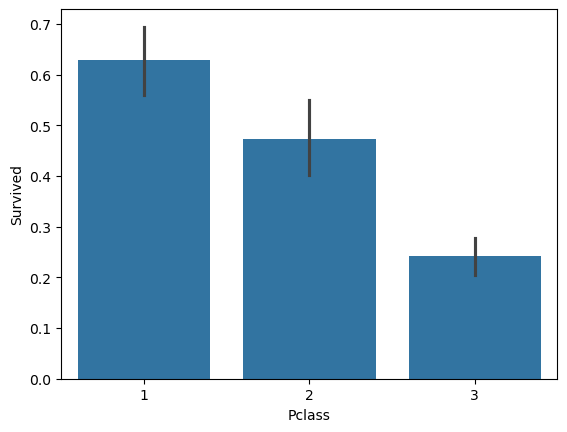

In [46]:
sns.barplot(data=train_df, x='Pclass', y='Survived', estimator='mean') #barplot calculates mean by default, but can change to sum or median

<Axes: xlabel='Age', ylabel='Count'>

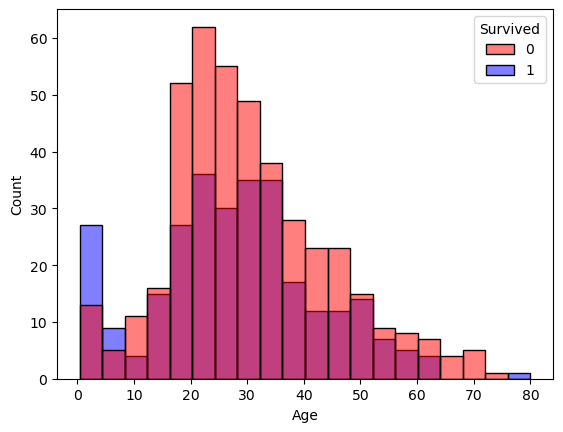

In [ ]:
sns.histplot(data=train_df, x='Age', hue='Survived',palette=['red', 'blue'])

<Axes: xlabel='SibSp', ylabel='Count'>

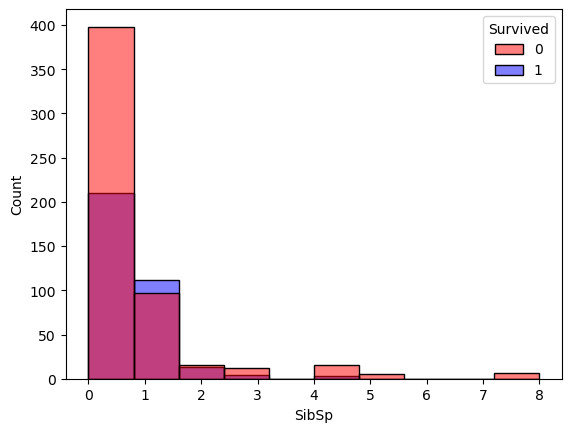

In [41]:
sns.histplot(data=train_df, x='SibSp', bins=10, hue='Survived',palette=['red', 'blue'])

<Axes: xlabel='Fare', ylabel='Count'>

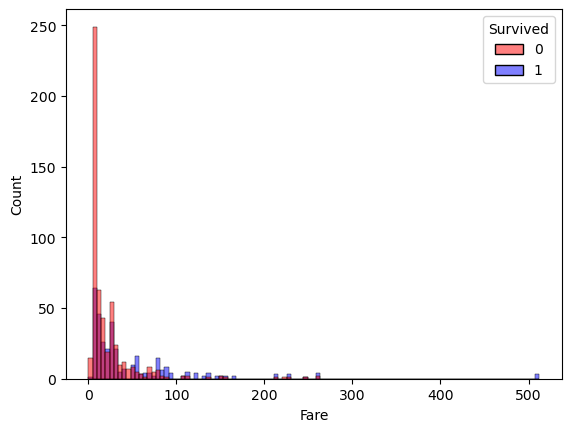

In [43]:
sns.histplot(data=train_df, x='Fare', hue='Survived', palette=['red', 'blue'])

<Axes: xlabel='Sex', ylabel='Survived'>

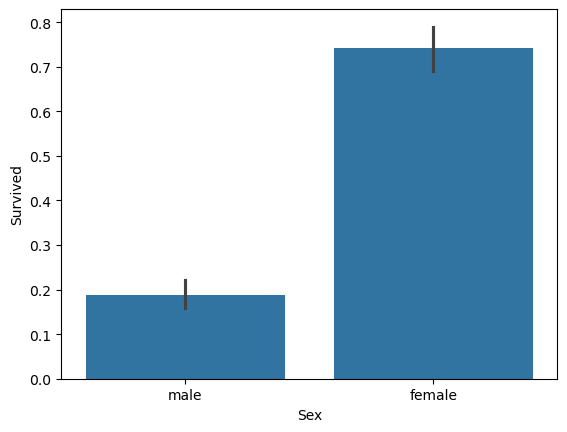

In [44]:
sns.barplot(data=train_df, x='Sex', y='Survived')

<Axes: xlabel='Sex', ylabel='count'>

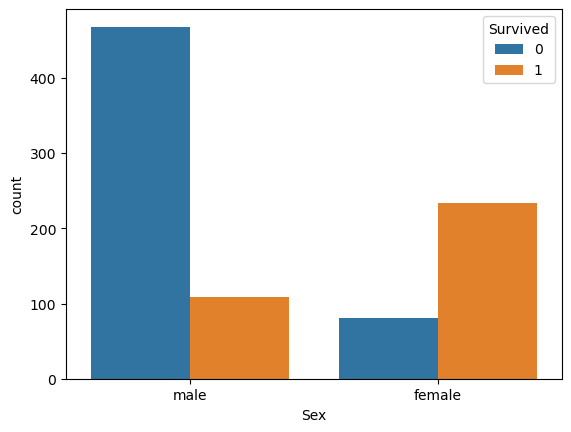

In [45]:
sns.countplot(data=train_df, x='Sex', hue='Survived')

<Axes: xlabel='Ticket', ylabel='Count'>

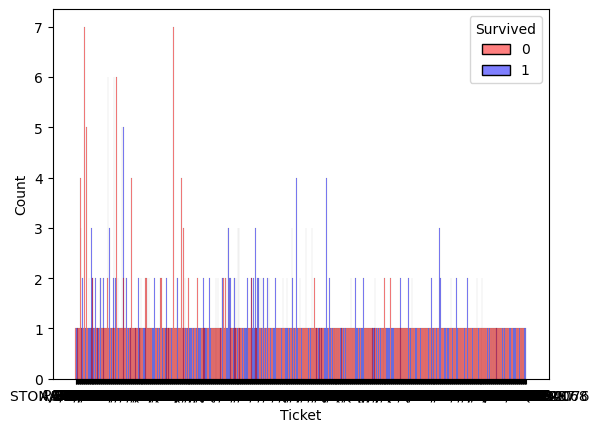

In [47]:
sns.histplot(data=train_df, x='Ticket', hue='Survived', palette=['red', 'blue'])

<Axes: xlabel='Pclass', ylabel='count'>

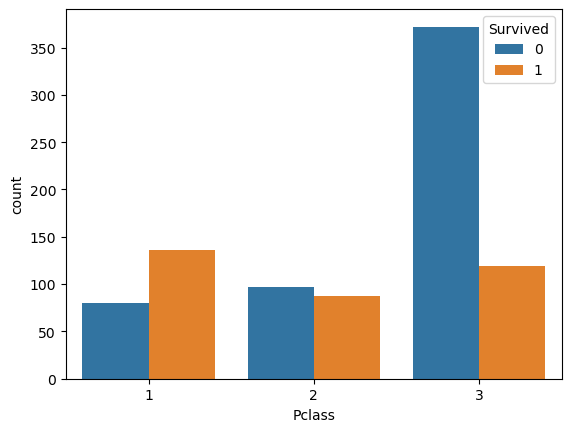

In [49]:
sns.countplot(data=train_df, x='Pclass', hue='Survived')

In [52]:
sorted(train_df['Cabin'].dropna().unique())

['A10',
 'A14',
 'A16',
 'A19',
 'A20',
 'A23',
 'A24',
 'A26',
 'A31',
 'A32',
 'A34',
 'A36',
 'A5',
 'A6',
 'A7',
 'B101',
 'B102',
 'B18',
 'B19',
 'B20',
 'B22',
 'B28',
 'B3',
 'B30',
 'B35',
 'B37',
 'B38',
 'B39',
 'B4',
 'B41',
 'B42',
 'B49',
 'B5',
 'B50',
 'B51 B53 B55',
 'B57 B59 B63 B66',
 'B58 B60',
 'B69',
 'B71',
 'B73',
 'B77',
 'B78',
 'B79',
 'B80',
 'B82 B84',
 'B86',
 'B94',
 'B96 B98',
 'C101',
 'C103',
 'C104',
 'C106',
 'C110',
 'C111',
 'C118',
 'C123',
 'C124',
 'C125',
 'C126',
 'C128',
 'C148',
 'C2',
 'C22 C26',
 'C23 C25 C27',
 'C30',
 'C32',
 'C45',
 'C46',
 'C47',
 'C49',
 'C50',
 'C52',
 'C54',
 'C62 C64',
 'C65',
 'C68',
 'C7',
 'C70',
 'C78',
 'C82',
 'C83',
 'C85',
 'C86',
 'C87',
 'C90',
 'C91',
 'C92',
 'C93',
 'C95',
 'C99',
 'D',
 'D10 D12',
 'D11',
 'D15',
 'D17',
 'D19',
 'D20',
 'D21',
 'D26',
 'D28',
 'D30',
 'D33',
 'D35',
 'D36',
 'D37',
 'D45',
 'D46',
 'D47',
 'D48',
 'D49',
 'D50',
 'D56',
 'D6',
 'D7',
 'D9',
 'E10',
 'E101',
 'E12',
 

<Axes: xlabel='Cabin', ylabel='Count'>

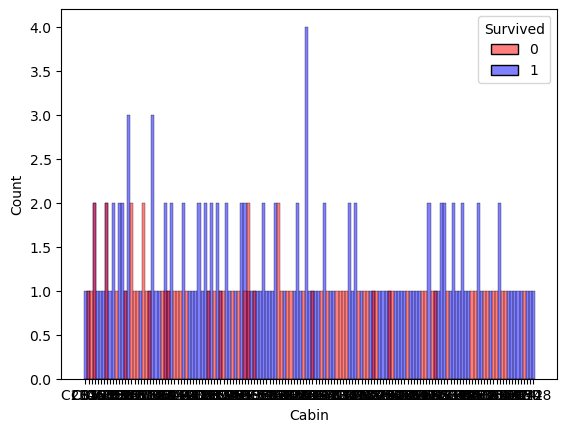

In [53]:
sns.histplot(data=train_df, x='Cabin', hue='Survived', palette=['red', 'blue'])

## Checking Null Values

In [55]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Handling Null values

As we can see age and embarked have null values. We fill them up with Median instead of mean because age might be skewed.
- Dont worry about Cabin as it will be dropped later

We dont have to manually fill up null values as SimpleImputer() in the One-hot encoding step will handle it. 

If you want to do it manually, below is the example:
- train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())
- train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

### Dropping Columns

Here we are dropping PassengerId, Name, Ticket, Cabin. 

How do we know what to drop before we even check the correlation?

At this stage, we are just using common sense as we know things like name and ticket and passangerId will have no effect on survival. While cabin might have effect on survival becuase some cabin will have more survival kits, but becuase it has too many null values which makes the data unreliable 

In [63]:
train_df = train_df.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId'])

Now we want to check correlation of each feature, but becuase some of them are string, corr() wont work, so we need to encode them first.

But instead of using one-hot encoding pipeline because that only works for building model. We use .get_dummies() that quickly returns a separate numerical data frame so we can play with it

In [85]:
train_df_encoded = pd.get_dummies(train_df, columns=['Sex', 'Embarked'])
train_df_encoded.corr()['Survived'].sort_values(ascending=False)

Survived      1.000000
Sex_female    0.543351
Fare          0.257307
Embarked_C    0.168240
Parch         0.081629
FamilySize    0.016639
Embarked_Q    0.003650
SibSp        -0.035322
Age          -0.064910
Embarked_S   -0.149683
IsAlone      -0.203367
Pclass       -0.338481
Sex_male     -0.543351
Name: Survived, dtype: float64

Here we see that being female and paying a higher fare significantly increased survival chances, while being male, in a lower class, or traveling alone significantly decreased them.

A negative correlation means that as that feature's value increases, survival decreases.
For example:
- Pclass = -0.34 — higher Pclass number means lower class (1=first, 3=third), so as Pclass goes up (worse class), survival goes down
- Sex_male = -0.54 — being male (1) means lower chance of survival
- IsAlone = -0.20 — traveling alone (1) means lower chance of survival

And positive means as the value increases, survival increases:
- Sex_female = +0.54 — being female (1) means higher chance of survival
- Fare = +0.26 — paying more means higher survival (likely because expensive tickets = higher class cabins = closer to lifeboats)

<Axes: >

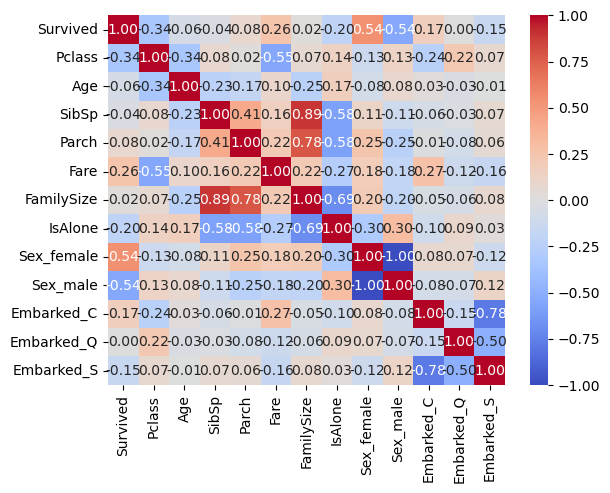

In [ ]:
sns.heatmap(train_df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f")

## Feature Engineering

### Feature Aggregation

In [70]:
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1

create a family size column as in the above SibSp bar plot, we saw that those with family tend to survive more so we want to find out exactly how many family members

In [71]:
train_df['IsAlone'] = (train_df['FamilySize'] == 1).astype(int)

<Axes: xlabel='FamilySize', ylabel='Survived'>

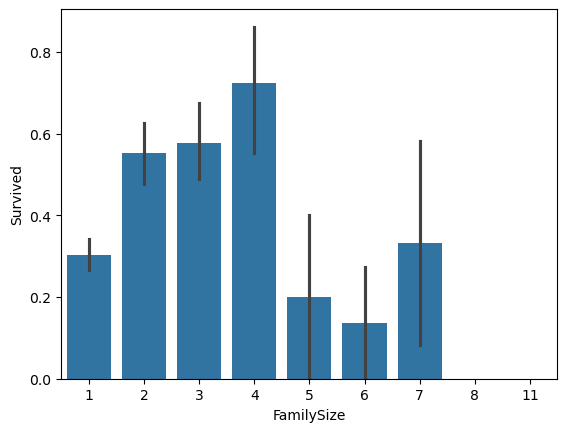

In [72]:
sns.barplot(data=train_df, x='FamilySize', y='Survived')

In [74]:
print(train_df.columns)

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'FamilySize', 'IsAlone'],
      dtype='object')


In [76]:
train_df.dtypes

Survived        int64
Pclass          int64
Sex            object
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked       object
FamilySize      int64
IsAlone         int64
dtype: object

### Encoding

In [77]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [78]:
numeric_features = ['Age', 'Fare', 'Pclass', 'SibSp', 'Parch', 'FamilySize', 'IsAlone']
categorical_features = ['Sex', 'Embarked'] 

In [79]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [81]:
train_df.dtypes

Survived        int64
Pclass          int64
Sex            object
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked       object
FamilySize      int64
IsAlone         int64
dtype: object